# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("D:\\Downloads\\2024-05-marketing-campaign-analysis\\Marketing Campaign Analysis Dataset_May 2024.xlsx")
df.head()

,Campaign,Date,City/Location,Latitude,Longitude,Channel,Device,Ad,Impressions,"CTR, %",Clicks,Daily Average CPC,"Spend, GBP",Conversions,"Total conversion value, GBP",Likes (Reactions),Shares,Comments
0,Spring,2023-03-01,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1110.8,0.0185,20.54980,1.3915,28.595047,1,51.840,45.0,4.0,3.0
1,Spring,2023-03-02,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1296.6,0.0110,14.26260,0.7245,10.333254,2,40.320,14.0,17.0,10.5
2,Spring,2023-03-03,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1264.4,0.0132,16.69008,0.3795,6.333885,4,53.760,24.0,1.0,7.5
3,Spring,2023-03-04,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,837.8,0.0159,13.32102,0.5750,7.659586,3,25.920,59.0,10.0,6.0
4,Spring,2023-03-05,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1599.0,0.0144,23.02560,0.8280,19.065197,2,108.192,44.0,17.0,1.5


In [3]:
df.columns

Index(['Campaign', 'Date', 'City/Location', 'Latitude', 'Longitude', 'Channel',
       'Device', 'Ad', 'Impressions', 'CTR, %', 'Clicks', 'Daily Average CPC',
       'Spend, GBP', 'Conversions', 'Total conversion value, GBP',
       'Likes (Reactions)', 'Shares', 'Comments'],
      dtype='str')

In [4]:
import scipy.stats as stats
from scipy.stats import skew, kurtosis, pearsonr
print("All libraries loaded successfully!")

All libraries loaded successfully!


# 1. DATA COMPOSITION REPORT

In [5]:
print("="*80)
print("DATA COMPOSITION REPORT")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n" + "="*80)
print("Column Information:")
print("="*80)
print(df.info())
print("\n" + "="*80)
print("Data Types Summary:")
print("="*80)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"{dtype}: {count} columns")

print("\n" + "="*80)
print("Missing Values Analysis:")
print("="*80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0]
if len(missing_data) == 0:
    print("✓ No missing values detected in the dataset")
else:
    print(missing_data.to_string(index=False))

print("\n" + "="*80)
print("Basic Statistics Summary:")
print("="*80)
print(df.describe().round(3))

DATA COMPOSITION REPORT

Dataset Shape: 9900 rows × 18 columns

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Campaign                     9900 non-null   str           
 1   Date                         9900 non-null   datetime64[us]
 2   City/Location                9900 non-null   str           
 3   Latitude                     9900 non-null   float64       
 4   Longitude                    9900 non-null   float64       
 5   Channel                      9900 non-null   str           
 6   Device                       9900 non-null   str           
 7   Ad                           9900 non-null   str           
 8   Impressions                  9900 non-null   float64       
 9   CTR, %                       9900 non-null   float64       
 10  Clicks                       9900 n

# 2. DATA DISTRIBUTION REPORT

In [6]:
print("="*80)
print("DISTRIBUTION ANALYSIS")
print("="*80)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Statistical measures for each numeric column
dist_stats = pd.DataFrame({
    'Column': numeric_cols,
    'Mean': [df[col].mean() for col in numeric_cols],
    'Median': [df[col].median() for col in numeric_cols],
    'Std Dev': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Q1': [df[col].quantile(0.25) for col in numeric_cols],
    'Q3': [df[col].quantile(0.75) for col in numeric_cols],
    'IQR': [df[col].quantile(0.75) - df[col].quantile(0.25) for col in numeric_cols],
    'Skewness': [skew(df[col].dropna()) for col in numeric_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in numeric_cols]
})

print("\nDistribution Statistics:")
print(dist_stats.round(3).to_string(index=False))

print("\n" + "="*80)
print("Skewness & Kurtosis Interpretation:")
print("="*80)
for idx, row in dist_stats.iterrows():
    skew_val = row['Skewness']
    kurt_val = row['Kurtosis']
    col_name = row['Column']
    
    # Skewness interpretation
    if abs(skew_val) < 0.5:
        skew_interpretation = "Fairly Symmetrical"
    elif skew_val > 0.5:
        skew_interpretation = "Right Skewed (Positive)"
    else:
        skew_interpretation = "Left Skewed (Negative)"
    
    # Kurtosis interpretation
    if kurt_val > 0:
        kurt_interpretation = "Heavy-tailed (Leptokurtic)"
    elif kurt_val < 0:
        kurt_interpretation = "Light-tailed (Platykurtic)"
    else:
        kurt_interpretation = "Normal-tailed (Mesokurtic)"
    
    print(f"\n{col_name}:")
    print(f"  Skewness: {skew_val:.3f} - {skew_interpretation}")
    print(f"  Kurtosis: {kurt_val:.3f} - {kurt_interpretation}")

DISTRIBUTION ANALYSIS

Distribution Statistics:
                     Column     Mean   Median  Std Dev    Min      Max       Q1       Q3     IQR  Skewness  Kurtosis
                   Latitude   52.494   52.489    0.807 51.507   53.484   51.507   53.484   1.977     0.008    -1.500
                  Longitude   -1.424   -1.899    0.927 -2.245   -0.128   -2.245   -0.128   2.117     0.634    -1.500
                Impressions 1479.338 1436.750  660.540  1.000 3847.000 1025.275 1910.025 884.750     0.292    -0.078
                     CTR, %    0.012    0.012    0.004  0.000    0.026    0.009    0.015   0.006     0.155    -0.250
                     Clicks   18.342   17.013   10.247  0.000   61.572   10.798   24.667  13.869     0.645     0.245
          Daily Average CPC    0.904    0.840    0.563  0.000    2.691    0.471    1.233   0.761     0.606    -0.135
                 Spend, GBP   16.490   12.691   14.471  0.000  109.008    5.531   23.381  17.850     1.449     2.581
                

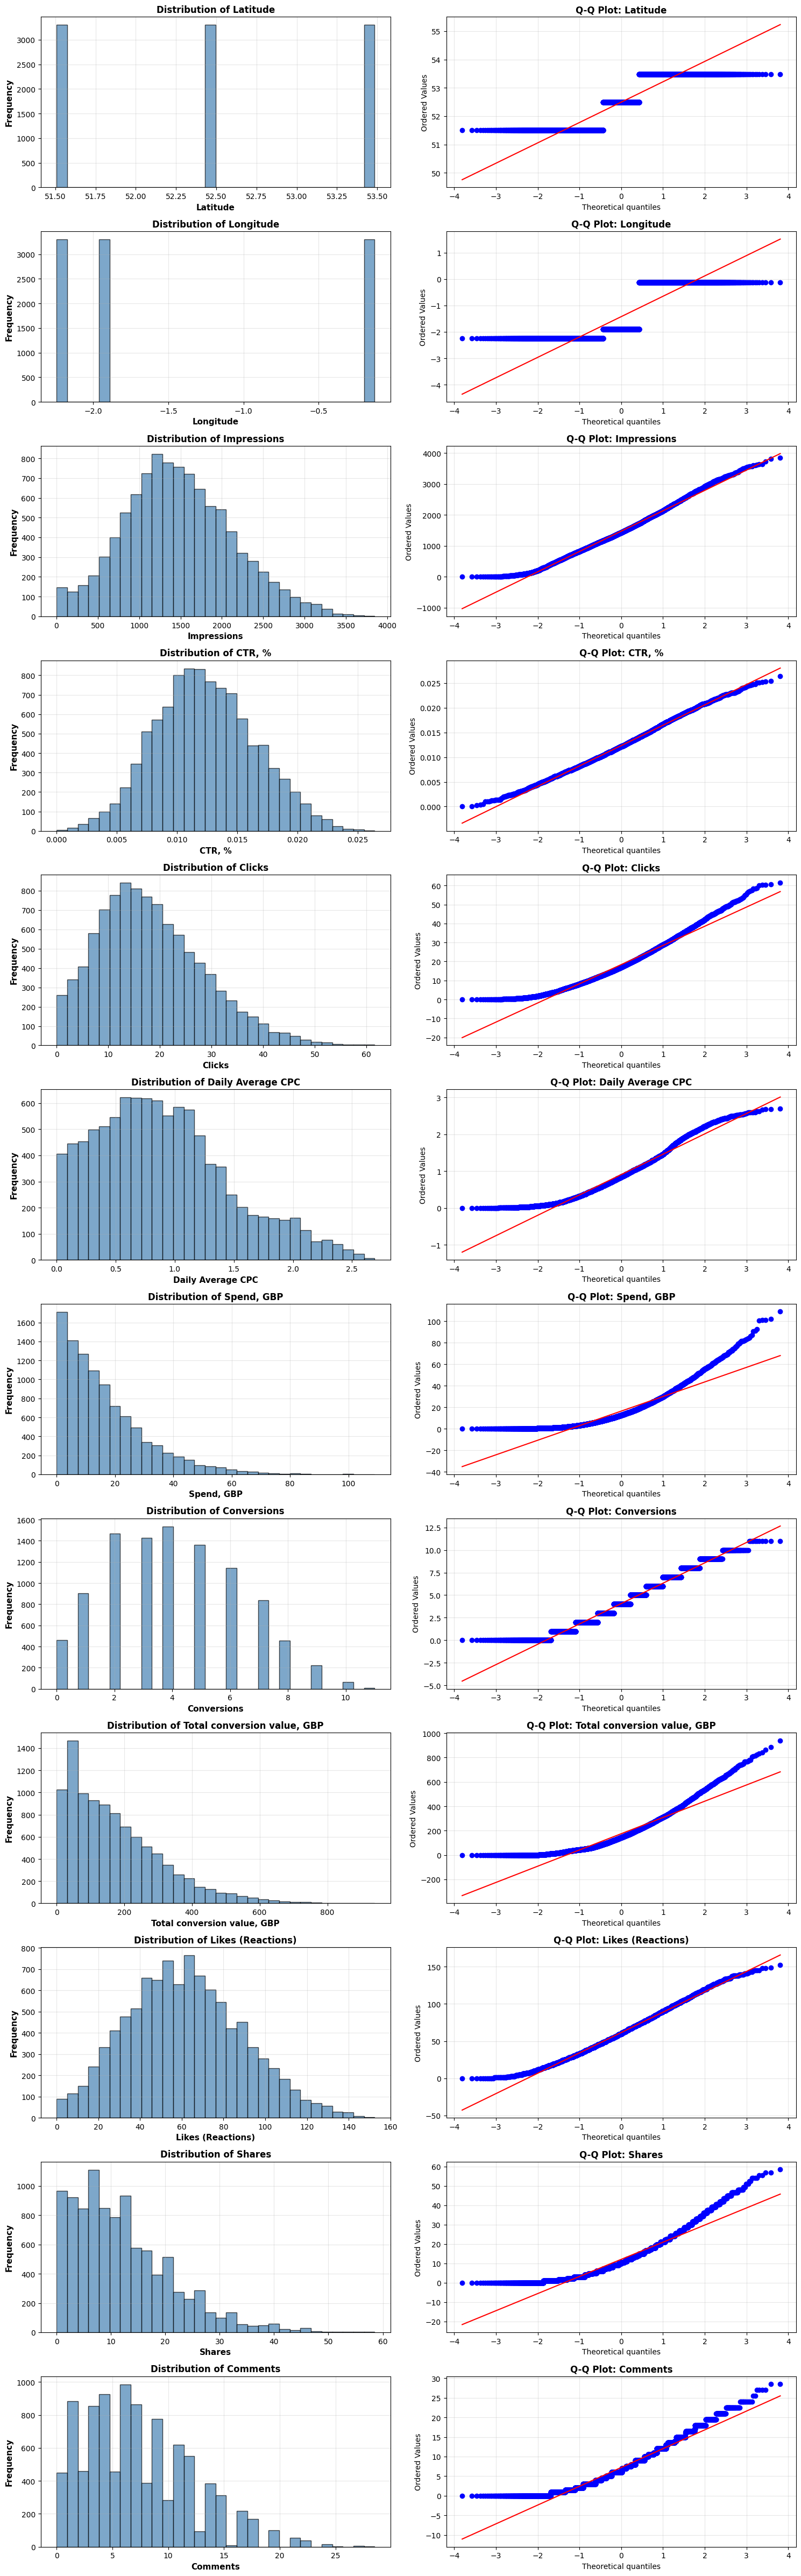


✓ Distribution plots saved and displayed


In [7]:
# Distribution Visualizations - Histograms and KDE plots
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 4*len(numeric_cols)))

if len(numeric_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numeric_cols):
    # Histogram with KDE
    axes[idx, 0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx, 0].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(alpha=0.3)
    
    # Q-Q plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[idx, 1])
    axes[idx, 1].set_title(f'Q-Q Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Distribution plots saved and displayed")

# 3. DATA COMPARISON & STATISTICAL TESTING

In [8]:
print("="*80)
print("COMPARISON ANALYSIS")
print("="*80)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    print(f"\nCategorical Columns Found: {categorical_cols}")
    
    for cat_col in categorical_cols:
        print(f"\n{cat_col} - Value Counts:")
        print(df[cat_col].value_counts())
        print(f"Unique Values: {df[cat_col].nunique()}")
        
        # For each numeric column, perform group comparisons
        if numeric_cols:
            print(f"\n{cat_col} - Statistical Comparison (Mean values by category):")
            comparison_table = df.groupby(cat_col)[numeric_cols].agg(['mean', 'std', 'count']).round(3)
            print(comparison_table)

# Normality tests for numeric columns
print("\n" + "="*80)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("="*80)

normality_results = []
for col in numeric_cols:
    stat, p_value = stats.shapiro(df[col].dropna())
    is_normal = "Yes" if p_value > 0.05 else "No"
    normality_results.append({
        'Column': col,
        'Statistic': stat,
        'P-Value': p_value,
        'Normal (α=0.05)': is_normal
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.round(4).to_string(index=False))
print("\nInterpretation: P-Value > 0.05 indicates data follows normal distribution")

COMPARISON ANALYSIS

Categorical Columns Found: ['Campaign', 'City/Location', 'Channel', 'Device', 'Ad']

Campaign - Value Counts:
Campaign
Spring     3312
Summer     3312
Fall       3276
Name: count, dtype: int64
Unique Values: 3

Campaign - Statistical Comparison (Mean values by category):
         Latitude              Longitude              Impressions           \
             mean    std count      mean    std count        mean      std   
Campaign                                                                     
Fall       52.494  0.807  3276    -1.424  0.927  3276    1964.060  591.561   
Spring     52.494  0.807  3312    -1.424  0.927  3312    1434.665  510.916   
Summer     52.494  0.807  3312    -1.424  0.927  3312    1044.559  523.190   

               CTR, %  ... Total conversion value, GBP Likes (Reactions)  \
         count   mean  ...                       count              mean   
Campaign               ...                                                 
Fall      

# 3.1 INTERACTIVE COMPARISON VISUALIZATIONS - CAMPAIGN PERFORMANCE

In [9]:
print("="*80)
print("CAMPAIGN PERFORMANCE ANALYSIS")
print("="*80)

# Campaign performance metrics
if 'Campaign' in df.columns:
    campaign_stats = df.groupby('Campaign').agg({
        'Impressions': ['sum', 'mean'],
        'Clicks': ['sum', 'mean'],
        'CTR, %': 'mean',
        'Conversions': ['sum', 'mean'],
        'Spend, GBP': 'sum',
        'Total conversion value, GBP': 'sum'
    }).round(2)
    
    print("\nCampaign Performance Metrics:")
    print(campaign_stats)
    
    # Interactive Plotly boxplot for key metrics
    fig_impressions = px.box(df, x='Campaign', y='Impressions', 
                            title='Distribution of Impressions by Campaign',
                            color='Campaign', points='outliers',
                            labels={'Impressions': 'Impressions (count)'},
                            template='plotly_white')
    fig_impressions.update_layout(height=500, font=dict(size=12))
    fig_impressions.show()
    
    fig_clicks = px.box(df, x='Campaign', y='Clicks', 
                       title='Distribution of Clicks by Campaign',
                       color='Campaign', points='outliers',
                       labels={'Clicks': 'Clicks (count)'},
                       template='plotly_white')
    fig_clicks.update_layout(height=500, font=dict(size=12))
    fig_clicks.show()
    
    print("\n✓ Campaign comparison plots displayed")

CAMPAIGN PERFORMANCE ANALYSIS

Campaign Performance Metrics:
         Impressions             Clicks        CTR, % Conversions        \
                 sum     mean       sum   mean   mean         sum  mean   
Campaign                                                                  
Fall       6434259.0  1964.06  85106.33  25.98   0.01       14886  4.54   
Spring     4751611.4  1434.67  57657.98  17.41   0.01       12613  3.81   
Summer     3459578.4  1044.56  38821.71  11.72   0.01       12753  3.85   

         Spend, GBP Total conversion value, GBP  
                sum                         sum  
Campaign                                         
Fall       79313.93                   749006.03  
Spring     49554.52                   498285.14  
Summer     34381.61                   484409.26  



✓ Campaign comparison plots displayed


# 3.2 CHANNEL & DEVICE PERFORMANCE ANALYSIS

In [10]:
print("="*80)
print("CHANNEL & DEVICE PERFORMANCE ANALYSIS")
print("="*80)

if 'Channel' in df.columns:
    channel_stats = df.groupby('Channel').agg({
        'Impressions': 'mean',
        'Clicks': 'mean',
        'CTR, %': 'mean',
        'Spend, GBP': 'mean',
        'Conversions': 'mean'
    }).round(2)
    
    print("\nChannel Performance Metrics (Mean values):")
    print(channel_stats)
    
    # Interactive Plotly charts for Channel
    fig_channel_ctr = px.box(df, x='Channel', y='CTR, %', 
                            title='Click-Through Rate (CTR) by Channel',
                            color='Channel', points='outliers',
                            labels={'CTR, %': 'CTR (%)'},
                            template='plotly_white')
    fig_channel_ctr.update_layout(height=500, font=dict(size=12))
    fig_channel_ctr.show()
    
    fig_channel_spend = px.box(df, x='Channel', y='Spend, GBP', 
                              title='Spend Distribution by Channel',
                              color='Channel', points='outliers',
                              labels={'Spend, GBP': 'Spend (GBP)'},
                              template='plotly_white')
    fig_channel_spend.update_layout(height=500, font=dict(size=12))
    fig_channel_spend.show()

if 'Device' in df.columns:
    device_stats = df.groupby('Device').agg({
        'Impressions': 'mean',
        'Clicks': 'mean',
        'CTR, %': 'mean',
        'Conversions': 'mean',
        'Spend, GBP': 'mean'
    }).round(2)
    
    print("\nDevice Performance Metrics (Mean values):")
    print(device_stats)
    
    # Interactive Plotly charts for Device
    fig_device_conversions = px.box(df, x='Device', y='Conversions', 
                                   title='Conversions by Device Type',
                                   color='Device', points='outliers',
                                   labels={'Conversions': 'Conversions (count)'},
                                   template='plotly_white')
    fig_device_conversions.update_layout(height=500, font=dict(size=12))
    fig_device_conversions.show()
    
    fig_device_ctr = px.box(df, x='Device', y='CTR, %', 
                           title='Click-Through Rate (CTR) by Device',
                           color='Device', points='outliers',
                           labels={'CTR, %': 'CTR (%)'},
                           template='plotly_white')
    fig_device_ctr.update_layout(height=500, font=dict(size=12))
    fig_device_ctr.show()

print("\n✓ Channel and Device comparison plots displayed")

CHANNEL & DEVICE PERFORMANCE ANALYSIS

Channel Performance Metrics (Mean values):
           Impressions  Clicks  CTR, %  Spend, GBP  Conversions
Channel                                                        
Facebook       1648.36   21.20    0.01       21.70         3.98
Instagram      1466.86   20.79    0.01       19.21         4.72
Pinterest      1322.79   13.03    0.01        8.56         3.49



Device Performance Metrics (Mean values):
         Impressions  Clicks  CTR, %  Conversions  Spend, GBP
Device                                                       
Desktop      1171.75   17.95    0.01         4.31       17.42
Mobile       1786.93   18.73    0.01         3.83       15.56



✓ Channel and Device comparison plots displayed


# 3.3 GEOGRAPHIC & AD PERFORMANCE ANALYSIS

In [11]:
print("="*80)
print("GEOGRAPHIC & AD PERFORMANCE ANALYSIS")
print("="*80)

if 'City/Location' in df.columns:
    location_stats = df.groupby('City/Location').agg({
        'Impressions': 'mean',
        'Clicks': 'mean',
        'CTR, %': 'mean',
        'Conversions': 'mean',
        'Spend, GBP': 'mean'
    }).round(2).sort_values('CTR, %', ascending=False)
    
    print("\nTop 10 Locations by CTR:")
    print(location_stats.head(10))
    
    # Top performing locations - Interactive bar chart
    top_locations = df.groupby('City/Location')['CTR, %'].mean().nlargest(10).reset_index()
    fig_location_ctr = px.bar(top_locations, x='City/Location', y='CTR, %',
                             title='Top 10 Locations by Average CTR',
                             labels={'CTR, %': 'Average CTR (%)', 'City/Location': 'Location'},
                             template='plotly_white', color='CTR, %',
                             color_continuous_scale='RdYlGn')
    fig_location_ctr.update_layout(height=500, font=dict(size=11), 
                                  xaxis_tickangle=-45, showlegend=False)
    fig_location_ctr.show()

if 'Ad' in df.columns:
    ad_stats = df.groupby('Ad').agg({
        'Impressions': 'mean',
        'Clicks': 'mean',
        'CTR, %': 'mean',
        'Conversions': 'mean',
        'Spend, GBP': 'mean'
    }).round(2).sort_values('CTR, %', ascending=False)
    
    print("\nAd Performance Metrics (Mean values):")
    print(ad_stats)
    
    # Ad performance - Interactive comparison
    ad_summary = df.groupby('Ad').agg({
        'CTR, %': 'mean',
        'Conversions': 'mean',
        'Spend, GBP': 'mean'
    }).reset_index()
    
    fig_ad_performance = px.bar(ad_summary, x='Ad', y='CTR, %',
                               title='Click-Through Rate (CTR) by Ad',
                               color='CTR, %', color_continuous_scale='Viridis',
                               labels={'CTR, %': 'Average CTR (%)', 'Ad': 'Ad Type'},
                               template='plotly_white')
    fig_ad_performance.update_layout(height=500, font=dict(size=12), showlegend=False)
    fig_ad_performance.show()

print("\n✓ Geographic and Ad performance plots displayed")

GEOGRAPHIC & AD PERFORMANCE ANALYSIS

Top 10 Locations by CTR:
               Impressions  Clicks  CTR, %  Conversions  Spend, GBP
City/Location                                                      
Birmingham         1203.52   13.47    0.01         3.88       11.96
London             1718.59   22.51    0.01         3.96       20.21
Manchester         1515.90   19.05    0.01         4.36       17.29



Ad Performance Metrics (Mean values):
            Impressions  Clicks  CTR, %  Conversions  Spend, GBP
Ad                                                              
Collection      1601.28   21.41    0.01         3.85       14.58
Discount        1357.40   15.28    0.01         4.28       18.40



✓ Geographic and Ad performance plots displayed


# 4. DATA RELATIONSHIP ANALYSIS

In [12]:
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

print("\nPearson Correlation Matrix:")
print(correlation_matrix.round(3))

# Identify strong correlations (absolute value > 0.7)
print("\n" + "="*80)
print("Strong Correlations (|r| > 0.7):")
print("="*80)

strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlations found (|r| > 0.7)")

# Moderate correlations (0.5 < |r| <= 0.7)
print("\n" + "="*80)
print("Moderate Correlations (0.5 < |r| ≤ 0.7):")
print("="*80)

moderate_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if 0.5 < abs(correlation_matrix.iloc[i, j]) <= 0.7:
            moderate_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if moderate_corr:
    moderate_corr_df = pd.DataFrame(moderate_corr)
    print(moderate_corr_df.to_string(index=False))
else:
    print("No moderate correlations found")

CORRELATION ANALYSIS

Pearson Correlation Matrix:
                             Latitude  Longitude  Impressions  CTR, %  Clicks  \
Latitude                        1.000     -0.931       -0.124  -0.043  -0.137   
Longitude                      -0.931      1.000        0.224   0.113   0.250   
Impressions                    -0.124      0.224        1.000   0.031   0.787   
CTR, %                         -0.043      0.113        0.031   1.000   0.596   
Clicks                         -0.137      0.250        0.787   0.596   1.000   
Daily Average CPC               0.009     -0.006       -0.073   0.087  -0.016   
Spend, GBP                     -0.082      0.157        0.447   0.406   0.604   
Conversions                     0.070     -0.044        0.026   0.160   0.111   
Total conversion value, GBP     0.104     -0.082       -0.021   0.043  -0.006   
Likes (Reactions)               0.013      0.038        0.143  -0.096   0.038   
Shares                         -0.015      0.071        0.2

In [13]:
# Interactive Correlation heatmap visualization using Plotly
fig_corr = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(correlation_matrix.values, 2),
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar=dict(title="Correlation")
))

fig_corr.update_layout(
    title='Interactive Correlation Matrix Heatmap',
    xaxis_title='Variables',
    yaxis_title='Variables',
    height=600,
    width=800,
    template='plotly_white',
    font=dict(size=11)
)
fig_corr.show()

print("\n✓ Interactive correlation heatmap displayed")

# Interpretation
print("\nInterpretation:")
print("  • Red colors: Positive correlation (variables move together)")
print("  • Blue colors: Negative correlation (inverse relationship)")
print("  • White: Weak or no correlation")


✓ Interactive correlation heatmap displayed

Interpretation:
  • Red colors: Positive correlation (variables move together)
  • Blue colors: Negative correlation (inverse relationship)
  • White: Weak or no correlation


Note: Dataset has 12 numeric columns. Creating pairplot for first 5...


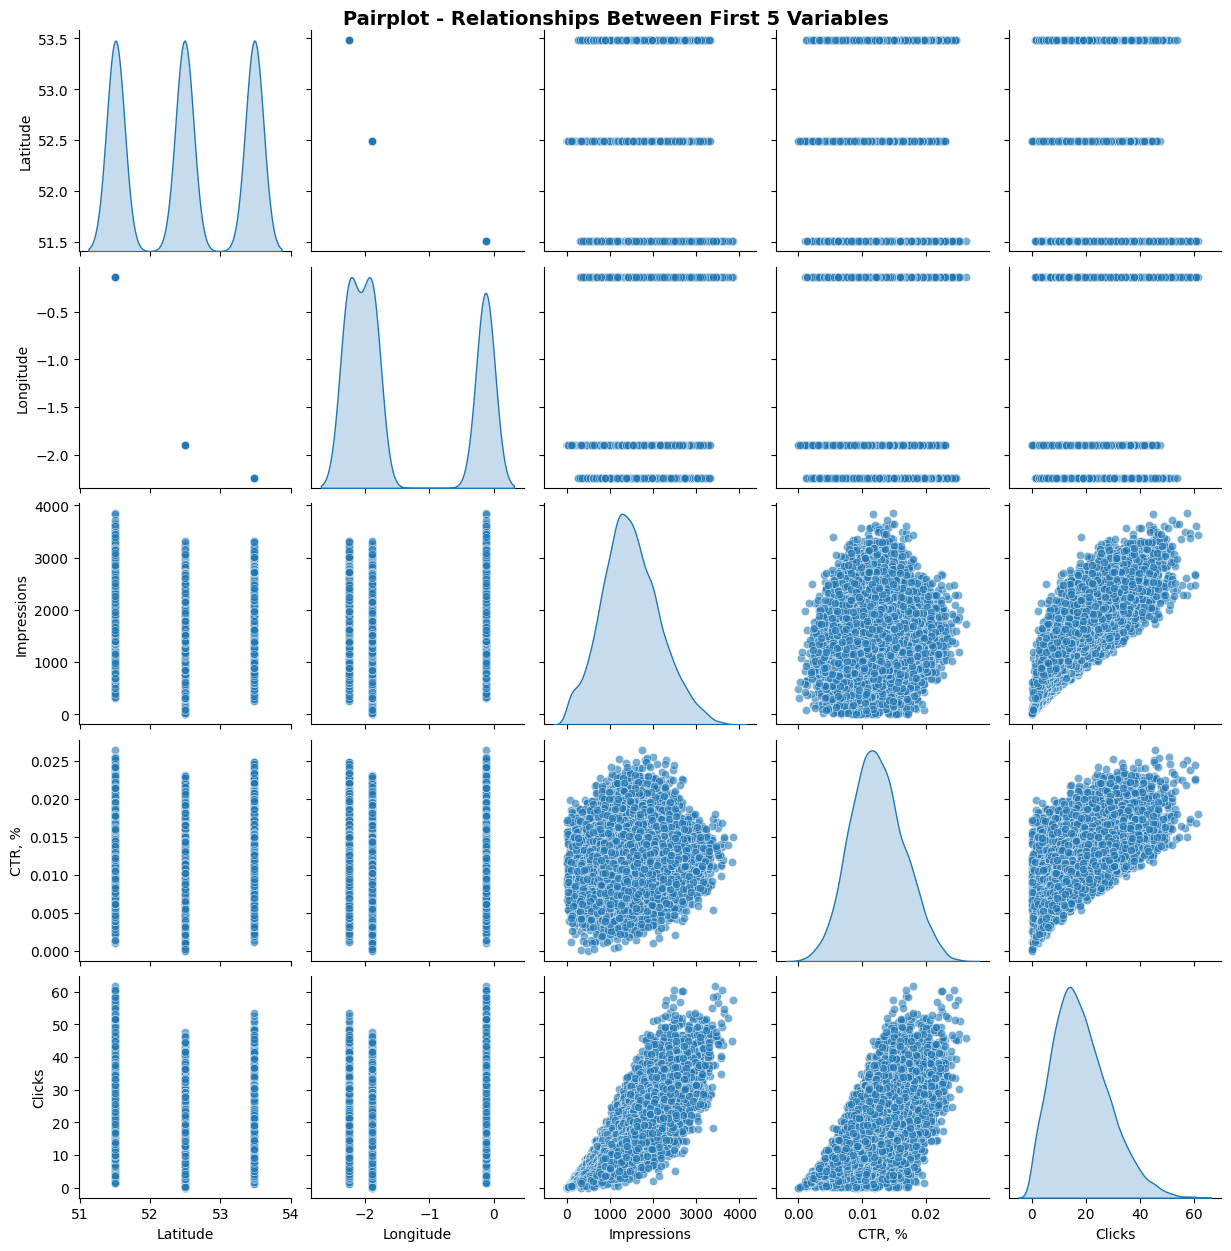

✓ Pairplot saved and displayed


In [14]:
# Pairplot visualization for relationships
if len(numeric_cols) <= 5:
    print("Creating pairplot...")
    pairplot_fig = sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
    pairplot_fig.fig.suptitle('Pairplot - Relationships Between Variables', 
                              fontsize=14, fontweight='bold', y=1.001)
    plt.savefig('pairplot_relationships.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Pairplot saved and displayed")
else:
    print(f"Note: Dataset has {len(numeric_cols)} numeric columns. Creating pairplot for first 5...")
    subset_cols = numeric_cols[:5]
    pairplot_fig = sns.pairplot(df[subset_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
    pairplot_fig.fig.suptitle(f'Pairplot - Relationships Between First 5 Variables', 
                              fontsize=14, fontweight='bold', y=1.001)
    plt.savefig('pairplot_relationships.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Pairplot saved and displayed")

# 5. EXECUTIVE SUMMARY & KEY INSIGHTS

In [15]:
print("="*80)
print("COMPREHENSIVE DATA ANALYSIS SUMMARY")
print("="*80)

summary_report = f"""
1. DATA COMPOSITION:
   • Total Records: {df.shape[0]:,}
   • Total Features: {df.shape[1]}
   • Data Types: {', '.join([f'{dtype} ({count})' for dtype, count in df.dtypes.value_counts().items()])}
   • Missing Values: {'None detected' if df.isnull().sum().sum() == 0 else f'{df.isnull().sum().sum()} cells'}

2. NUMERIC VARIABLES ({len(numeric_cols)}):
   {', '.join(numeric_cols) if numeric_cols else 'None'}

3. CATEGORICAL VARIABLES ({len(categorical_cols)}):
   {', '.join(categorical_cols) if categorical_cols else 'None'}

4. DISTRIBUTION INSIGHTS:
"""

print(summary_report)

# Add distribution insights
for col in numeric_cols:
    skew_val = skew(df[col].dropna())
    if abs(skew_val) < 0.5:
        shape = "Approximately normal distribution"
    elif skew_val > 0:
        shape = f"Right-skewed (positively skewed, skewness={skew_val:.2f})"
    else:
        shape = f"Left-skewed (negatively skewed, skewness={skew_val:.2f})"
    
    print(f"   • {col}: {shape}")

if categorical_cols:
    print("\n5. KEY CATEGORICAL INSIGHTS:")
    for cat_col in categorical_cols:
        print(f"   • {cat_col}: {df[cat_col].nunique()} unique values")
        top_val = df[cat_col].value_counts().index[0]
        top_pct = (df[cat_col].value_counts().values[0] / len(df) * 100)
        print(f"     - Most common: '{top_val}' ({top_pct:.1f}% of records)")

print("\n6. CORRELATION HIGHLIGHTS:")
if strong_corr:
    print(f"   • {len(strong_corr)} strong correlation(s) found (|r| > 0.7)")
else:
    print("   • No strong correlations found (|r| > 0.7)")

if moderate_corr:
    print(f"   • {len(moderate_corr)} moderate correlation(s) found (0.5 < |r| ≤ 0.7)")
else:
    print("   • No moderate correlations found")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nGenerated Files:")
print("  ✓ distribution_analysis.png - Distribution plots and Q-Q plots")
print("  ✓ comparison_analysis.png - Box plots for categorical comparisons")
print("  ✓ correlation_heatmap.png - Correlation matrix visualization")
print("  ✓ pairplot_relationships.png - Pairplot of variable relationships")
print("\nAll analysis components are ready for reporting.")

COMPREHENSIVE DATA ANALYSIS SUMMARY

1. DATA COMPOSITION:
   • Total Records: 9,900
   • Total Features: 18
   • Data Types: float64 (11), str (5), datetime64[us] (1), int64 (1)
   • Missing Values: None detected

2. NUMERIC VARIABLES (12):
   Latitude, Longitude, Impressions, CTR, %, Clicks, Daily Average CPC, Spend, GBP, Conversions, Total conversion value, GBP, Likes (Reactions), Shares, Comments

3. CATEGORICAL VARIABLES (5):
   Campaign, City/Location, Channel, Device, Ad

4. DISTRIBUTION INSIGHTS:

   • Latitude: Approximately normal distribution
   • Longitude: Right-skewed (positively skewed, skewness=0.63)
   • Impressions: Approximately normal distribution
   • CTR, %: Approximately normal distribution
   • Clicks: Right-skewed (positively skewed, skewness=0.65)
   • Daily Average CPC: Right-skewed (positively skewed, skewness=0.61)
   • Spend, GBP: Right-skewed (positively skewed, skewness=1.45)
   • Conversions: Approximately normal distribution
   • Total conversion value,